# 03 - EDA & Statistical Analysis

Here I used the cleaned daily and hourly data to understand the main energy patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
daily = pd.read_csv("../01_Data/processed/daily_energy.csv", parse_dates=["date"])
hourly = pd.read_csv("../01_Data/processed/hourly_energy.csv", parse_dates=["date_time"])

In [3]:
daily.head()

,date,daily_kwh,avg_voltage,avg_intensity,avg_reactive_power,records,coverage_pct,dayofweek,month,is_weekend
0,2006-12-17,56.507667,240.087028,9.999028,0.156949,1440,100.0,6,12,1
1,2006-12-18,36.730433,241.231694,6.421667,0.112356,1440,100.0,0,12,0
2,2006-12-19,27.769900,241.999313,4.926389,0.104821,1440,100.0,1,12,0
3,2006-12-20,37.095800,242.308063,6.467361,0.111804,1440,100.0,2,12,0
4,2006-12-21,28.618567,241.041903,5.028194,0.100115,1440,100.0,3,12,0


## Basic statistics

In [4]:
print(daily["daily_kwh"].describe().round(2))

count    725.00
mean      26.58
std       11.30
min        4.17
25%       19.03
50%       26.34
75%       32.87
max       79.56
Name: daily_kwh, dtype: float64


In [5]:
print("Average daily energy:", round(daily["daily_kwh"].mean(), 2), "kWh")
print("Median daily energy:", round(daily["daily_kwh"].median(), 2), "kWh")

Average daily energy: 26.58 kWh
Median daily energy: 26.34 kWh


## Daily trend

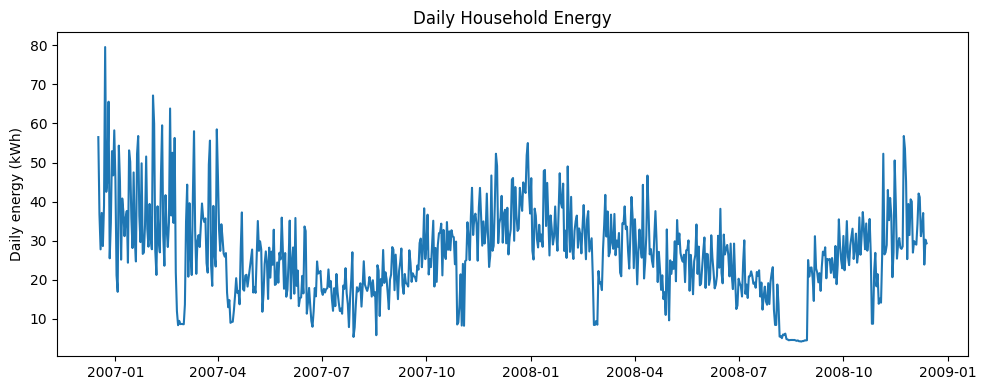

In [6]:
plt.figure(figsize=(10,4))
plt.plot(daily["date"], daily["daily_kwh"])
plt.ylabel("Daily energy (kWh)")
plt.title("Daily Household Energy")
plt.tight_layout()
plt.show()

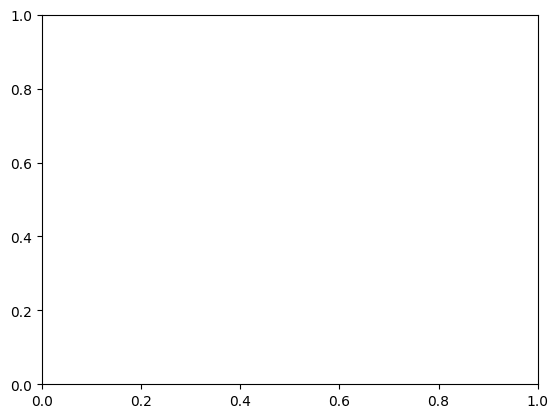

In [7]:
plt.savefig("../04_Visuals/eda/01_daily_energy_trend.png", dpi=150)
plt.show()

## Hourly profile

In [8]:
hourly_avg = hourly.groupby("hour")["energy_kwh"].mean()

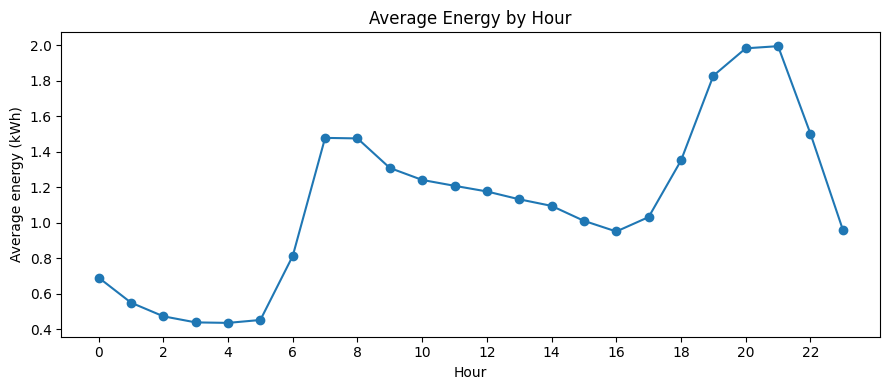

In [9]:
plt.figure(figsize=(9,4))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.xlabel("Hour")
plt.ylabel("Average energy (kWh)")
plt.title("Average Energy by Hour")
plt.xticks(range(0,24,2))
plt.tight_layout()
plt.show()

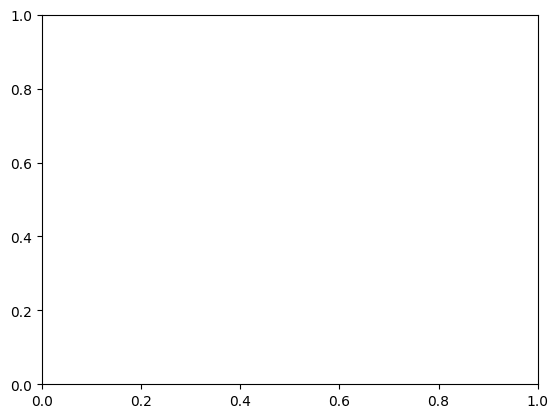

In [10]:
plt.savefig("../04_Visuals/eda/02_hourly_profile.png", dpi=150)
plt.show()

## Weekday vs weekend

In [11]:
weekday = daily.loc[daily["is_weekend"] == 0, "daily_kwh"]
weekend = daily.loc[daily["is_weekend"] == 1, "daily_kwh"]

In [12]:
print("Weekday mean:", round(weekday.mean(), 2))
print("Weekend mean:", round(weekend.mean(), 2))

Weekday mean: 25.01
Weekend mean: 30.54


In [13]:
uplift = (weekend.mean()/weekday.mean() - 1) * 100
print("Weekend uplift:", round(uplift, 2), "%")

Weekend uplift: 22.08 %


/tmp/ipykernel_3180/3965166558.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekday, weekend], labels=["Weekday", "Weekend"])


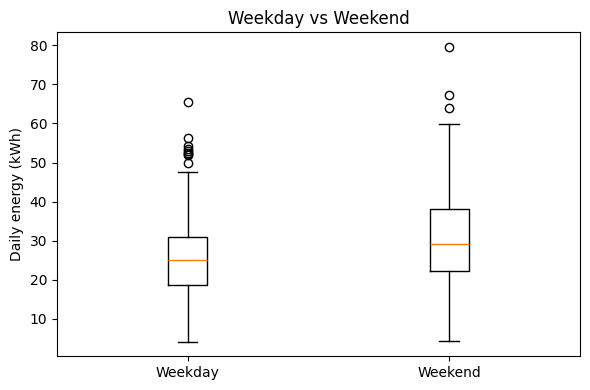

In [14]:
plt.figure(figsize=(6,4))
plt.boxplot([weekday, weekend], labels=["Weekday", "Weekend"])
plt.ylabel("Daily energy (kWh)")
plt.title("Weekday vs Weekend")
plt.tight_layout()
plt.show()

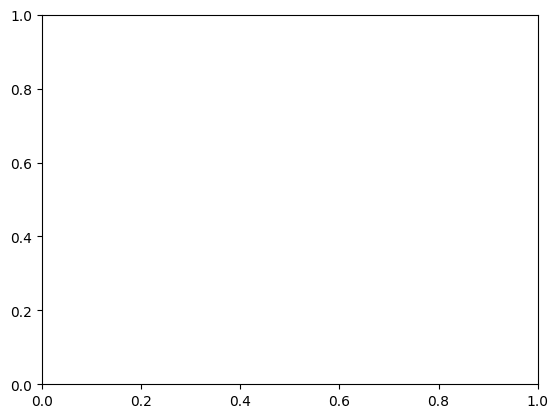

In [15]:
plt.savefig("../04_Visuals/eda/03_weekday_weekend.png", dpi=150)
plt.show()

## Correlation

In [16]:
corr_cols = ["daily_kwh", "avg_voltage", "avg_intensity", "avg_reactive_power"]
print(daily[corr_cols].corr().round(2))

                    daily_kwh  avg_voltage  avg_intensity  avg_reactive_power
daily_kwh                1.00         0.16           1.00                0.14
avg_voltage              0.16         1.00           0.14               -0.09
avg_intensity            1.00         0.14           1.00                0.16
avg_reactive_power       0.14        -0.09           0.16                1.00


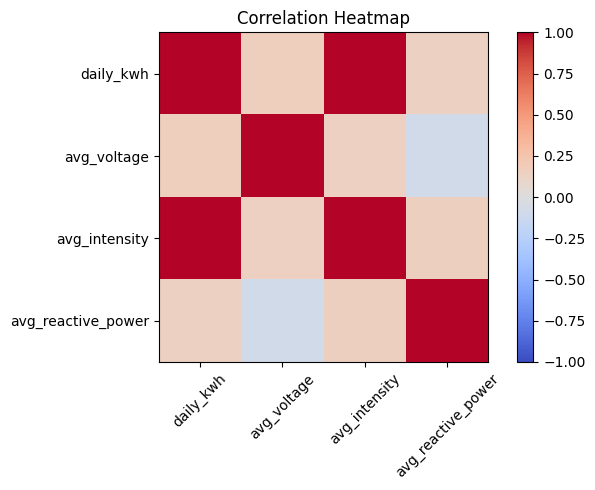

In [17]:
plt.figure(figsize=(7,5))
plt.imshow(daily[corr_cols].corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

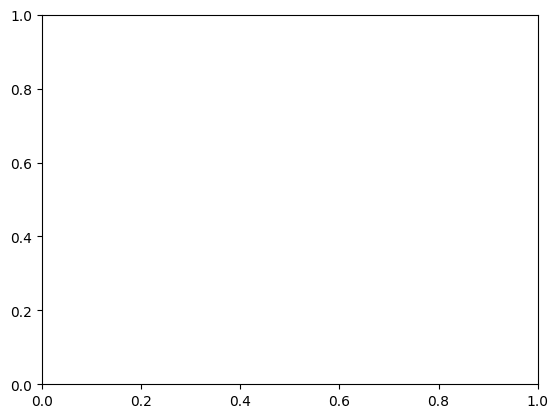

In [18]:
plt.savefig("../04_Visuals/eda/04_correlation_heatmap.png", dpi=150)
plt.show()

## Simple statistical test

I used a t-test to check whether weekday and weekend daily energy are different.

In [19]:
t_stat, p_value = stats.ttest_ind(weekday, weekend, equal_var=False)
print("t-stat:", round(t_stat, 2))
print("p-value:", round(p_value, 4))

t-stat: -5.28
p-value: 0.0


## What I found

The main patterns from this notebook are daily demand changes, a clear hourly profile, and different weekday/weekend use. These features will help in the next ML steps.